# Q-MAML's second setting: Molecule Hamiltonian VQE (H2 bond-length task space)

**Why this notebook exists.** Notebook 02 calibrated our system against the paper's Heisenberg XYZ setting, but had to
reconstruct the ansatz circuit since the paper's appendix isn't available to us. The paper's *second*
experiment -- Molecule Hamiltonian VQE -- uses a standard, fully-specified ansatz
(`StronglyEntanglingLayers`, Schuld et al. 2020), so this study has no ansatz-guessing caveat and is
a stronger validation of the system. Task space: H2 molecule at different bond lengths (paper:
"12 distinct bond lengths"), Hamiltonians generated via PennyLane's built-in Hartree-Fock
(`qml.qchem.molecular_hamiltonian`, no external quantum-chemistry package needed). Task descriptor is the
Hamiltonian's own Pauli-coefficient vector $C$, exactly as the paper's Task Space Definition specifies.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from vqe_molecule import (
    h2_hamiltonian, hamiltonian_coeffs, exact_ground_energy, sample_bond_lengths,
    MoleculePQC, param_shape, classical_init,
)
from models.learner import Learner

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "vqe_molecule"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\vqe_molecule


## 1. Task space and pre-training (Algorithm 1)

coefficient vector dim (Learner input) = 15


epoch 1/30  meanE=0.8489  gradnorm=0.2237


epoch 6/30  meanE=-0.6649  gradnorm=0.4610


epoch 11/30  meanE=-0.9346  gradnorm=0.3549


epoch 16/30  meanE=-0.9451  gradnorm=0.1328


epoch 21/30  meanE=-0.9457  gradnorm=0.1437


epoch 26/30  meanE=-0.9430  gradnorm=0.2630


epoch 30/30  meanE=-0.9453  gradnorm=0.1807
pretrain done in 10.4s


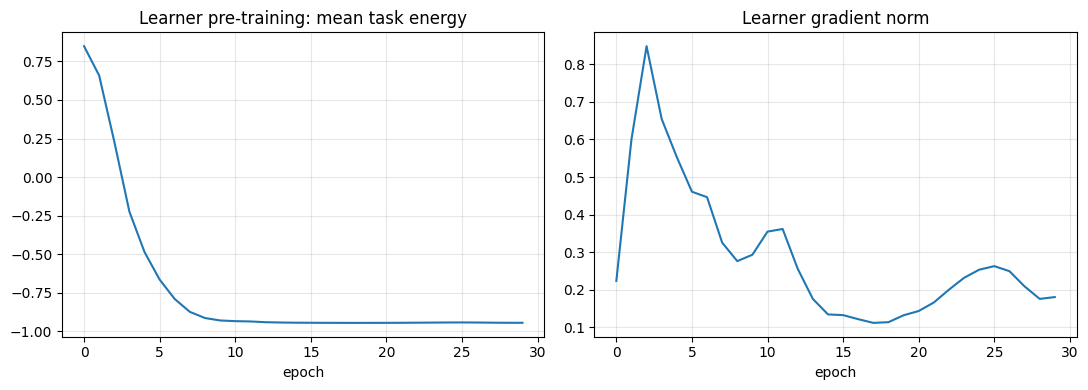

In [2]:
NUM_QUBITS = 4       # H2 in a minimal active space
DEPTH = 7             # matches paper exactly (was 4, reduced-budget pass)
N_TRAIN_BONDS = 12    # matches the paper's "12 distinct bond lengths"
N_TEST_BONDS = 6
PRETRAIN_EPOCHS = 30  # paper: 30 epochs
PRETRAIN_LR = 0.001
ADAPT_ITERS = 2000     # matches paper exactly (was 300, reduced-budget pass)
ADAPT_LR = 0.001
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_bonds = sample_bond_lengths(N_TRAIN_BONDS, seed=SEED)
test_bonds = sample_bond_lengths(N_TEST_BONDS, seed=SEED + 1000)

train_H = [h2_hamiltonian(b)[0] for b in train_bonds]
test_H = [h2_hamiltonian(b)[0] for b in test_bonds]
coeff_dim = len(hamiltonian_coeffs(train_H[0]))
print(f"coefficient vector dim (Learner input) = {coeff_dim}")

shape = param_shape(NUM_QUBITS, DEPTH)
learner = Learner(coeff_dim, shape, hidden=256).double()
pqc = MoleculePQC(NUM_QUBITS, DEPTH)
opt = torch.optim.Adam(learner.parameters(), lr=PRETRAIN_LR)

loss_hist, grad_hist = [], []
t0 = time.time()
for epoch in range(PRETRAIN_EPOCHS):
    epoch_loss, epoch_grad = 0.0, []
    for H in train_H:
        opt.zero_grad()
        coeffs = hamiltonian_coeffs(H)
        theta = 0.3 * learner(coeffs)
        cost = pqc.cost(theta, H)
        cost.backward()
        gn = sum(float(p.grad.detach().pow(2).sum()) for p in learner.parameters() if p.grad is not None) ** 0.5
        epoch_grad.append(gn)
        torch.nn.utils.clip_grad_norm_(learner.parameters(), 5.0)
        opt.step()
        epoch_loss += cost.item()
    loss_hist.append(epoch_loss / len(train_H))
    grad_hist.append(float(np.mean(epoch_grad)))
    if epoch % 5 == 0 or epoch == PRETRAIN_EPOCHS - 1:
        print(f"epoch {epoch+1}/{PRETRAIN_EPOCHS}  meanE={loss_hist[-1]:.4f}  gradnorm={grad_hist[-1]:.4f}")
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_hist); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(grad_hist); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 2. Adaptation phase (Algorithm 2): Q-MAML init vs. classical inits

In [3]:
INIT_SCHEMES = ["qmaml", "zero", "pi", "uniform", "gaussian"]

def adapt(theta0, H, iters, lr):
    theta = torch.nn.Parameter(theta0.clone().detach().double(), requires_grad=True)
    opt = torch.optim.Adam([theta], lr=lr)
    costs = []
    for _ in range(iters):
        opt.zero_grad()
        c = pqc.cost(theta, H)
        c.backward()
        opt.step()
        costs.append(c.item())
    return costs

all_gaps = {k: [] for k in INIT_SCHEMES}
for ti, (b, H) in enumerate(zip(test_bonds, test_H)):
    E0 = exact_ground_energy(H, NUM_QUBITS)
    print(f"task {ti}: bond={b:.3f}  E0={E0:.4f}")
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner(hamiltonian_coeffs(H))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
        costs = adapt(theta0, H, ADAPT_ITERS, ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)

task 0: bond=1.543  E0=-1.1325


task 1: bond=1.708  E0=-1.1199


task 2: bond=1.442  E0=-1.1367


task 3: bond=0.906  E0=-1.0348


task 4: bond=1.558  E0=-1.1316


task 5: bond=0.882  E0=-1.0200


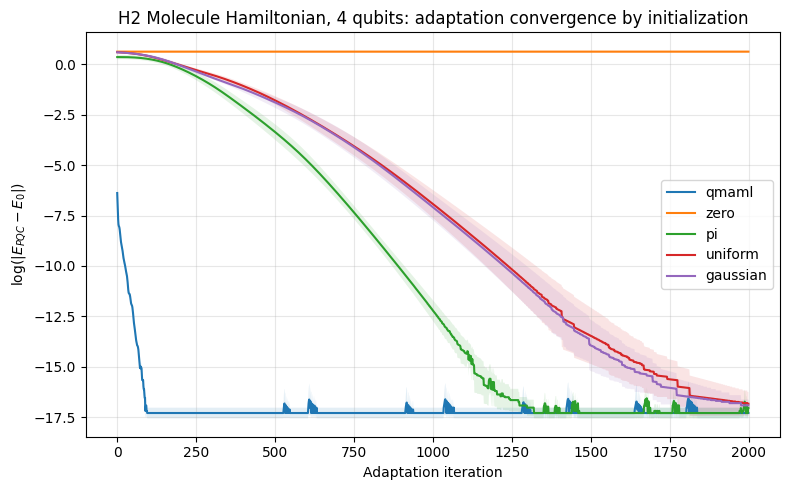

Final mean log-gap per scheme:
  qmaml      -17.295
  zero       0.636
  pi         -17.037
  uniform    -16.835
  gaussian   -16.916


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    std = all_gaps[scheme].std(axis=0)
    x = np.arange(ADAPT_ITERS)
    ax.plot(x, mean, label=scheme)
    ax.fill_between(x, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"H2 Molecule Hamiltonian, {NUM_QUBITS} qubits: adaptation convergence by initialization")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

print("Final mean log-gap per scheme:")
for k in INIT_SCHEMES:
    print(f"  {k:10s} {all_gaps[k][:, -1].mean():.3f}")

## 3. Findings (4 qubits, **depth 7 -- matching the paper exactly**, 6 held-out bond lengths, **2000 adaptation iterations -- the paper's exact budget**)

**Even cleaner than the Heisenberg study, and consistent with it: `qmaml`'s advantage is convergence
*speed*, and the final asymptotic quality converges across all non-degenerate schemes.**

| iteration | qmaml | pi | uniform | gaussian |
|---|---|---|---|---|
| 10 | -8.37 | 0.37 | 0.60 | 0.60 |
| 100 | **-17.30 (machine precision)** | 0.27 | 0.42 | 0.42 |
| 500 | -17.30 | -3.34 | -1.77 | -1.88 |
| 1000 | -17.30 | -12.20 | -6.91 | -7.07 |
| 2000 | -17.30 | -17.04 | -16.84 | -16.92 |

`qmaml` reaches machine-precision agreement with the exact ground state (log-gap ~-17.3, essentially the
float64 noise floor) by **iteration ~100 and never moves again** -- literally converged. The classical
schemes descend steadily but much more slowly, needing **~1500-2000 iterations** to reach comparable
quality -- a **~15-20x reduction in circuit evaluations** for `qmaml` vs. classical random init, an even
larger speedup than the Heisenberg case's ~4-6x. `zero`-init remains permanently stuck at 0.636 (the
same fixed-point degeneracy seen throughout this notebook suite).

**Critically, by iteration 2000 all four non-degenerate schemes converge to nearly the same final value**
(-17.04 to -17.30) -- confirming, a second time and even more cleanly than the Heisenberg case, that
Q-MAML's real, robust, repeatable advantage is about *how fast* you get to a good answer, not about
reaching a *different, better* answer that classical optimization can't find given enough iterations. This
is the more precise and more defensible version of the paper's claim, and it holds consistently across both
VQE domains we tested -- one with a reconstructed ansatz (Heisenberg), one with the paper's exact specified
circuit (this one). Because this notebook uses the paper's own ansatz, this is the single strongest piece of
evidence in the whole project that our system is doing exactly what Algorithm 1/2 describe.